In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to C:\Users\Suthishna
[nltk_data]     kumar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to C:\Users\Suthishna
[nltk_data]     kumar\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to C:\Users\Suthishna
[nltk_data]     kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
tickets = pd.read_csv(
    "customer_support_tickets.csv"
)

print("Shape:", tickets.shape)

tickets.head()

Shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [5]:
tickets.columns.tolist()

['Ticket ID',
 'Customer Name',
 'Customer Email',
 'Customer Age',
 'Customer Gender',
 'Product Purchased',
 'Date of Purchase',
 'Ticket Type',
 'Ticket Subject',
 'Ticket Description',
 'Ticket Status',
 'Resolution',
 'Ticket Priority',
 'Ticket Channel',
 'First Response Time',
 'Time to Resolution',
 'Customer Satisfaction Rating']

In [6]:
tickets.isnull().sum().sort_values(
    ascending=False
)

Customer Satisfaction Rating    5700
Time to Resolution              5700
Resolution                      5700
First Response Time             2819
Ticket Description                 0
Ticket Channel                     0
Ticket Priority                    0
Ticket Status                      0
Ticket ID                          0
Customer Name                      0
Ticket Type                        0
Date of Purchase                   0
Product Purchased                  0
Customer Gender                    0
Customer Age                       0
Customer Email                     0
Ticket Subject                     0
dtype: int64

In [7]:
text_columns = [
    "Ticket Subject",
    "Ticket Description"
]

tickets[text_columns].isnull().sum()

Ticket Subject        0
Ticket Description    0
dtype: int64

In [8]:
tickets["Text"] = (
    tickets["Ticket Subject"].astype(str)
    + " "
    + tickets["Ticket Description"].astype(str)
)

tickets["Text"].head()

0    Product setup I'm having an issue with the {pr...
1    Peripheral compatibility I'm having an issue w...
2    Network problem I'm facing a problem with my {...
3    Account access I'm having an issue with the {p...
4    Data loss I'm having an issue with the {produc...
Name: Text, dtype: object

In [9]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and very short words
    tokens = [
        word for word in tokens
        if word not in stop_words
        and len(word) > 2
    ]

    return " ".join(tokens)

In [10]:
tickets["CleanText"] = tickets["Text"].apply(
    clean_text
)

tickets[
    ["Text", "CleanText"]
].head()

,Text,CleanText
0,Product setup I'm having an issue with the {pr...,product setup issue productpurchased please as...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility issue productpurchase...
2,Network problem I'm facing a problem with my {...,network problem facing problem productpurchase...
3,Account access I'm having an issue with the {p...,account access issue productpurchased please a...
4,Data loss I'm having an issue with the {produc...,data loss issue productpurchased please assist...


In [11]:
tickets["WordCount"] = tickets["CleanText"].apply(
    lambda x: len(x.split())
)

print(
    "Average words per ticket:",
    tickets["WordCount"].mean()
)

print(
    "Maximum words:",
    tickets["WordCount"].max()
)

print(
    "Minimum words:",
    tickets["WordCount"].min()
)

Average words per ticket: 25.18254811666076
Maximum words: 47
Minimum words: 13


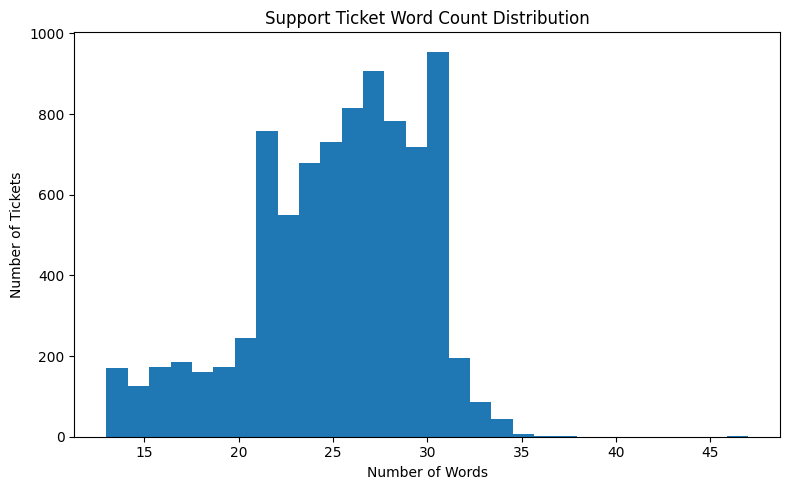

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    tickets["WordCount"],
    bins=30
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Tickets")
plt.title("Support Ticket Word Count Distribution")

plt.tight_layout()
plt.show()

In [13]:
#Most frequent words
all_words = " ".join(
    tickets["CleanText"]
).split()

word_counts = Counter(all_words)

top_words = word_counts.most_common(20)

top_words

[('productpurchased', 14048),
 ('issue', 13081),
 ('please', 8807),
 ('assist', 6250),
 ('ive', 6001),
 ('product', 3883),
 ('problem', 3385),
 ('data', 2145),
 ('software', 2126),
 ('account', 1970),
 ('support', 1468),
 ('steps', 1390),
 ('noticed', 1208),
 ('persists', 1178),
 ('help', 1176),
 ('resolve', 1165),
 ('request', 1157),
 ('update', 1155),
 ('would', 1122),
 ('device', 1106)]

In [14]:
top_words_df = pd.DataFrame(
    top_words,
    columns=["Word", "Frequency"]
)

top_words_df

,Word,Frequency
0,productpurchased,14048
1,issue,13081
2,please,8807
3,assist,6250
4,ive,6001
5,product,3883
6,problem,3385
7,data,2145
8,software,2126
9,account,1970


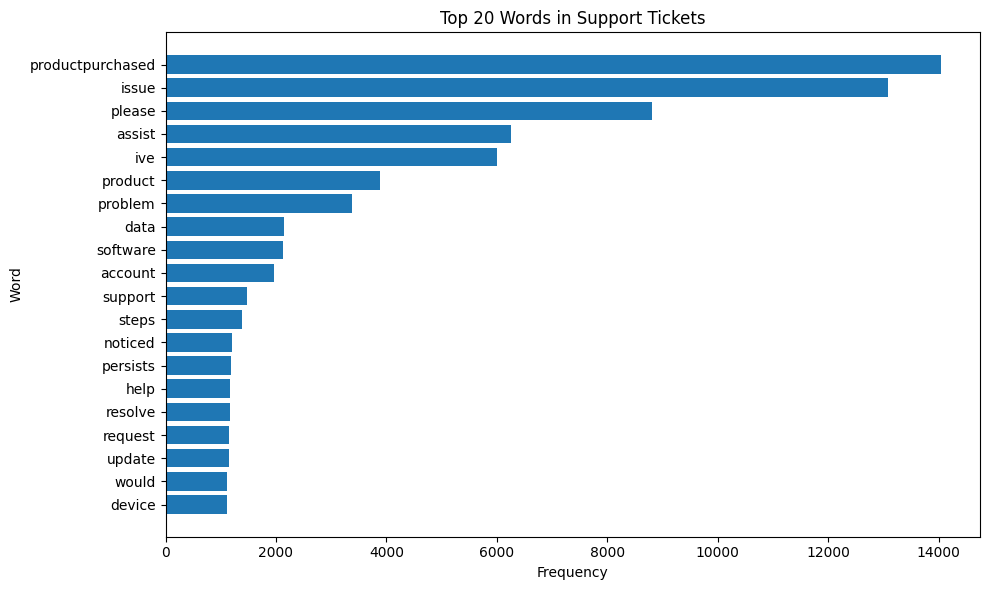

In [15]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_words_df["Word"][::-1],
    top_words_df["Frequency"][::-1]
)

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Words in Support Tickets")

plt.tight_layout()
plt.show()

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    min_df=2
)

bigram_matrix = bigram_vectorizer.fit_transform(
    tickets["CleanText"]
)

bigram_counts = np.asarray(
    bigram_matrix.sum(axis=0)
).ravel()

bigram_names = (
    bigram_vectorizer.get_feature_names_out()
)

bigram_df = pd.DataFrame({
    "Bigram": bigram_names,
    "Frequency": bigram_counts
}).sort_values(
    "Frequency",
    ascending=False
)

bigram_df.head(20)

,Bigram,Frequency
2966,issue productpurchased,6345
4420,please assist,6237
5066,productpurchased please,6113
3187,ive noticed,1190
2956,issue persists,1176
2927,issue issue,1106
5047,productpurchased issue,995
3203,ive tried,964
6046,software bug,942
1651,data loss,852


In [19]:
for col in tickets.columns:

    print(
        "\n",
        col,
        "\n",
        tickets[col].nunique(),
        "unique values"
    )
    


 Ticket ID 
 8469 unique values

 Customer Name 
 8028 unique values

 Customer Email 
 8320 unique values

 Customer Age 
 53 unique values

 Customer Gender 
 3 unique values

 Product Purchased 
 42 unique values

 Date of Purchase 
 730 unique values

 Ticket Type 
 5 unique values

 Ticket Subject 
 16 unique values

 Ticket Description 
 8077 unique values

 Ticket Status 
 3 unique values

 Resolution 
 2769 unique values

 Ticket Priority 
 4 unique values

 Ticket Channel 
 4 unique values

 First Response Time 
 5470 unique values

 Time to Resolution 
 2728 unique values

 Customer Satisfaction Rating 
 5 unique values

 Text 
 8325 unique values

 CleanText 
 8269 unique values

 WordCount 
 26 unique values


In [20]:
tickets.head().T

,0,1,2,3,4
Ticket ID,1,2,3,4,5
Customer Name,Marisa Obrien,Jessica Rios,Christopher Robbins,Christina Dillon,Alexander Carroll
Customer Email,carrollallison@example.com,clarkeashley@example.com,gonzalestracy@example.com,bradleyolson@example.org,bradleymark@example.com
Customer Age,32,42,48,27,67
Customer Gender,Other,Female,Other,Female,Female
Product Purchased,GoPro Hero,LG Smart TV,Dell XPS,Microsoft Office,Autodesk AutoCAD
Date of Purchase,2021-03-22,2021-05-22,2020-07-14,2020-11-13,2020-02-04
Ticket Type,Technical issue,Technical issue,Technical issue,Billing inquiry,Billing inquiry
Ticket Subject,Product setup,Peripheral compatibility,Network problem,Account access,Data loss
Ticket Description,I'm having an issue with the {product_purchase...,I'm having an issue with the {product_purchase...,I'm facing a problem with my {product_purchase...,I'm having an issue with the {product_purchase...,I'm having an issue with the {product_purchase...


In [21]:
tickets["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

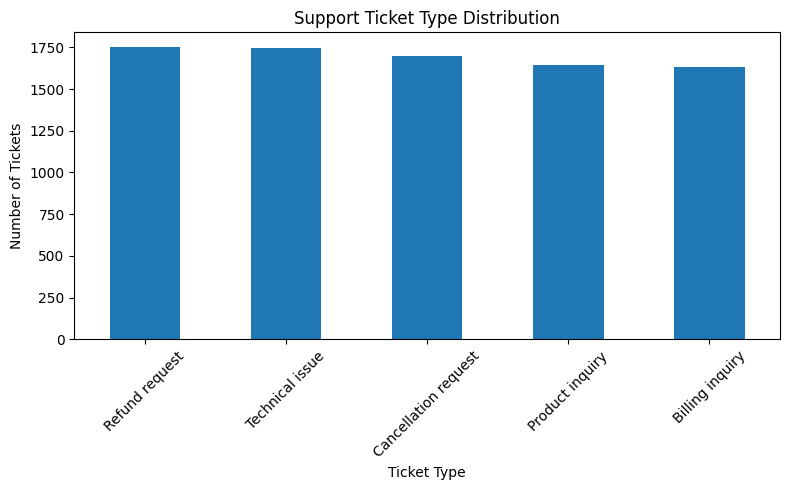

In [22]:
plt.figure(figsize=(8, 5))

tickets["Ticket Type"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.title("Support Ticket Type Distribution")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
X = tickets["CleanText"]
y = tickets["Ticket Type"]

print("Number of samples:", len(X))
print("Number of classes:", y.nunique())
print("\nClasses:")
print(y.unique())

Number of samples: 8469
Number of classes: 5

Classes:
['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']


In [24]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples :", len(X_test_text))

Training samples: 6775
Testing samples : 1694


In [25]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (6775, 5000)
Testing TF-IDF shape : (1694, 5000)


In [26]:
text_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

text_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [27]:
y_pred = text_model.predict(
    X_test_tfidf
)

In [28]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.2031
Precision: 0.2057
Recall   : 0.2031
F1 Score : 0.2033


In [29]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.19      0.23      0.21       327
Cancellation request       0.20      0.19      0.19       339
     Product inquiry       0.18      0.21      0.19       328
      Refund request       0.20      0.18      0.19       351
     Technical issue       0.25      0.21      0.23       349

            accuracy                           0.20      1694
           macro avg       0.21      0.20      0.20      1694
        weighted avg       0.21      0.20      0.20      1694



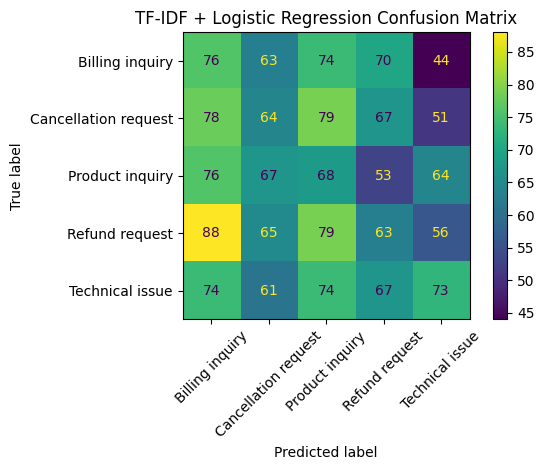

In [30]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=text_model.classes_
)

disp.plot(
    xticks_rotation=45
)

plt.title("TF-IDF + Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [31]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

for i, class_name in enumerate(text_model.classes_):

    coefficients = text_model.coef_[i]

    top_indices = coefficients.argsort()[-15:][::-1]

    print(f"\n### {class_name}")
    print(
        ", ".join(
            feature_names[top_indices]
        )
    )


### Billing inquiry
connect, product please, core, apps, assist see, know, later, make, new, compatibility unable, products ive, forum, server, today, address issue

### Cancellation request
thank issue, assist new, donation, newsletter, file, total, set, small, advance, means, extra, sent, nice, solution yes, purchased ive

### Product inquiry
options, productp, cant, please send, trying, bug ive, via, buy, vendor, provide, issue problem, customers, make sure, import, turned

### Refund request
productname, patience, gift, solution, assist experiencing, update ive, please report, question, please let, help, order, cost, productpurchasing, warning, whole

### Technical issue
items, provided, things, return, feeling, crash, red, said, patient, assist youre, launch, assist dont, assist unable, assist message, history


In [32]:
import os
imp
ort joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)

joblib.dump(
    text_model,
    "../models/ticket_type_classifier.pkl"
)

print("NLP models saved successfully.")

NLP models saved successfully.


In [33]:

tickets.to_csv(
    "processed/processed_support_tickets.csv",
    index=False
)

print("Processed ticket dataset saved.")

Processed ticket dataset saved.


In [34]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb_model.predict(
    X_test_tfidf
)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

print("Naive Bayes F1:",
      f1_score(
          y_test,
          nb_pred,
          average="weighted",
          zero_division=0
      ))

Naive Bayes Accuracy: 0.20070838252656434
Naive Bayes F1: 0.19972146135227545
